In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [53]:
training_data = pd.read_csv('./dataset/train.csv')
test_data = pd.read_csv('./dataset/test.csv')

In [54]:
print(training_data.shape)
print(test_data.shape)

(891, 12)
(418, 11)


In [55]:
training_data.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [56]:
training_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0    PassengerId  891 non-null    int64  
 1   Survived      891 non-null    int64  
 2   Pclass        891 non-null    int64  
 3   Name          891 non-null    str    
 4   Sex           891 non-null    str    
 5   Age           714 non-null    float64
 6   SibSp         891 non-null    int64  
 7   Parch         891 non-null    int64  
 8   Ticket        891 non-null    str    
 9   Fare          891 non-null    float64
 10  Cabin         204 non-null    str    
 11  Embarked      889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


# check the data balance

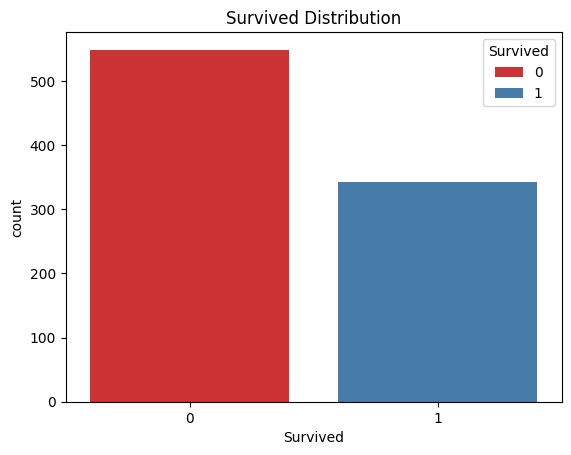

In [57]:
import seaborn as sns

sns.countplot(x='Survived', data=training_data, hue='Survived', palette='Set1')
plt.title('Survived Distribution')
plt.show()

# feature analysis

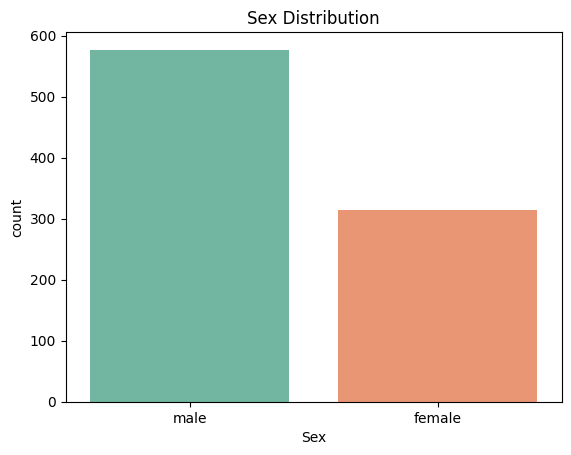

In [58]:
sns.countplot(x='Sex', data=training_data, palette='Set2', hue='Sex')
plt.title('Sex Distribution')
plt.show()

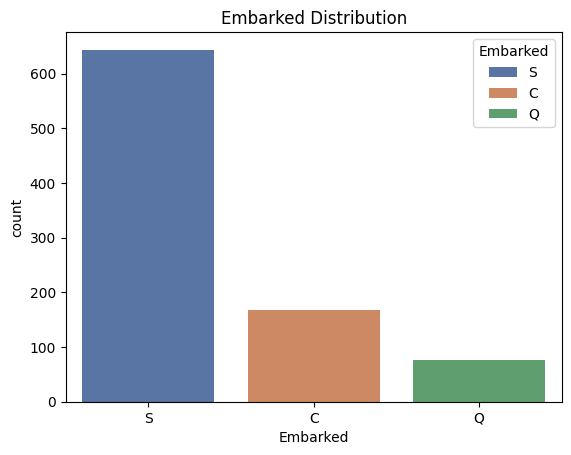

In [59]:
sns.countplot(x='Embarked', data=training_data, palette='deep', hue='Embarked')
plt.title('Embarked Distribution')
plt.show()

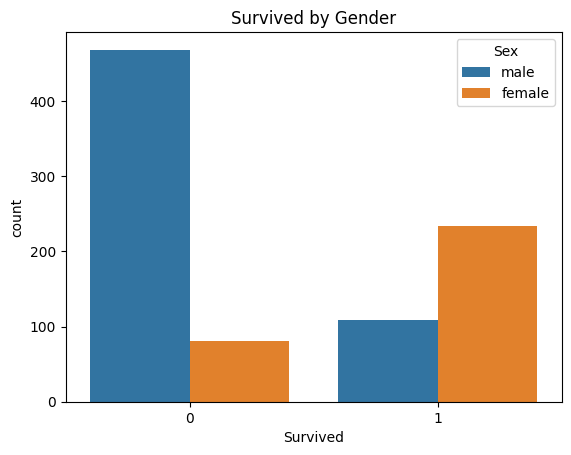

In [60]:
sns.countplot(x='Survived', data=training_data, hue='Sex')
plt.title('Survived by Gender')
plt.show()

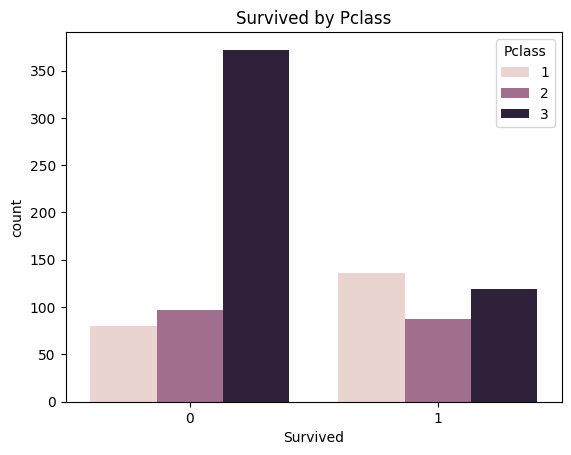

In [61]:
sns.countplot(x='Survived', data=training_data, hue='Pclass')
plt.title('Survived by Pclass')
plt.show()

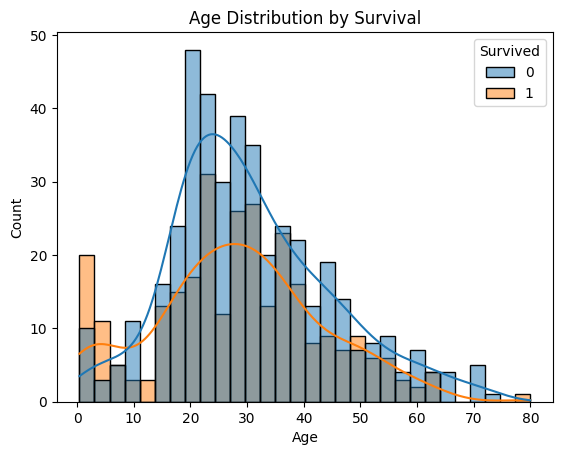

In [62]:
sns.histplot(x='Age', data=training_data, hue='Survived', bins=30, kde=True)
plt.title('Age Distribution by Survival')
plt.show()

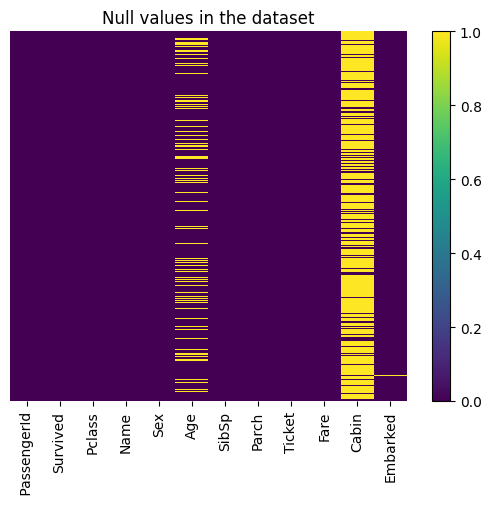

In [63]:
ax = sns.heatmap(training_data.isnull(), yticklabels=False, cbar=False, cmap='viridis')
ax.set_title('Null values in the dataset')
ax.figure.colorbar(ax.collections[0])
plt.show()


# data cleaning

In [64]:
# we drop the cabin column because it has too many missing values
training_data = training_data.drop('Cabin', axis=1)
test_data = test_data.drop('Cabin', axis=1)


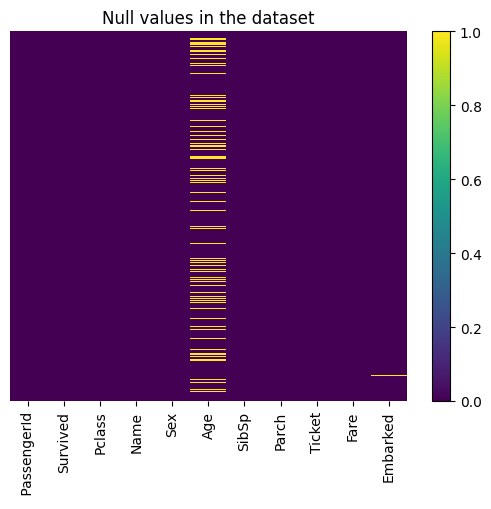

In [65]:
ax = sns.heatmap(training_data.isnull(), yticklabels=False, cbar=False, cmap='viridis')
ax.set_title('Null values in the dataset')
ax.figure.colorbar(ax.collections[0])
plt.show()


In [66]:
# for age column, we fill the missing values with the median of the age column
training_data['Age'] = training_data['Age'].fillna(training_data['Age'].median())
test_data['Age'] = test_data['Age'].fillna(test_data['Age'].median())

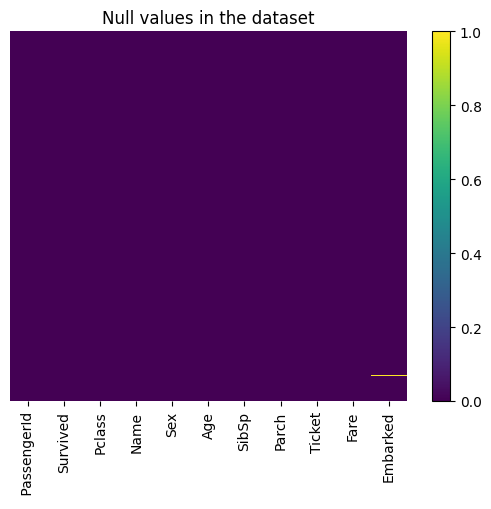

In [67]:
ax = sns.heatmap(training_data.isnull(), yticklabels=False, cbar=False, cmap='viridis')
ax.set_title('Null values in the dataset')
ax.figure.colorbar(ax.collections[0])
plt.show()


In [68]:
# fill missing values in the embarked column with the mode of the embarked column
training_data['Embarked'] = training_data['Embarked'].fillna(training_data['Embarked'].mode()[0])
test_data['Embarked'] = test_data['Embarked'].fillna(test_data['Embarked'].mode()[0])

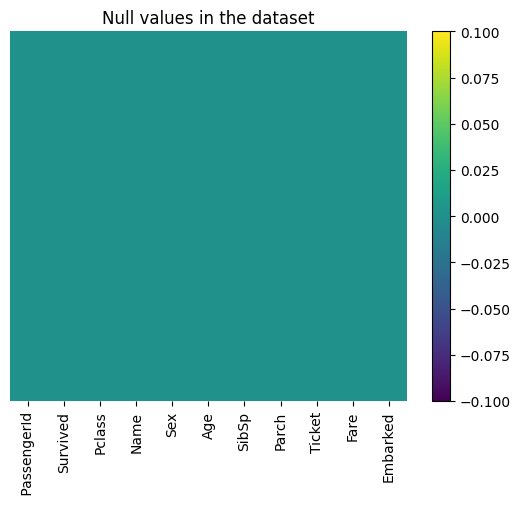

In [69]:
ax = sns.heatmap(training_data.isnull(), yticklabels=False, cbar=False, cmap='viridis')
ax.set_title('Null values in the dataset')
ax.figure.colorbar(ax.collections[0])
plt.show()


In [70]:
training_data.head(20)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S
5,6,0,3,"Moran, Mr. James",male,28.0,0,0,330877,8.4583,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,C


## categorical to numerical transformation

In [71]:
# hot encoding for categorical features
training_data['Sex'] = training_data['Sex'].map({'male': 0, 'female': 1})


In [72]:
training_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,S


In [73]:
# drop the Name
training_data.drop(['Name'], axis=1, inplace=True)
training_data.drop(['Ticket'], axis=1, inplace=True)
training_data.head(20)


,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,0,22.0,1,0,7.2500,S
1,2,1,1,1,38.0,1,0,71.2833,C
2,3,1,3,1,26.0,0,0,7.9250,S
3,4,1,1,1,35.0,1,0,53.1000,S
4,5,0,3,0,35.0,0,0,8.0500,S
5,6,0,3,0,28.0,0,0,8.4583,Q
6,7,0,1,0,54.0,0,0,51.8625,S
7,8,0,3,0,2.0,3,1,21.0750,S
8,9,1,3,1,27.0,0,2,11.1333,S
9,10,1,2,1,14.0,1,0,30.0708,C


In [74]:
df_training = pd.get_dummies(training_data, columns=['Embarked'], drop_first=False)

df_training.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,0,22.0,1,0,7.2500,False,False,True
1,2,1,1,1,38.0,1,0,71.2833,True,False,False
2,3,1,3,1,26.0,0,0,7.9250,False,False,True
3,4,1,1,1,35.0,1,0,53.1000,False,False,True
4,5,0,3,0,35.0,0,0,8.0500,False,False,True


In [75]:

df_training['Embarked_C'] = df_training['Embarked_C'].map({True: 1, False: 0})
df_training['Embarked_Q'] = df_training['Embarked_Q'].map({True: 1, False: 0})
df_training['Embarked_S'] = df_training['Embarked_S'].map({True: 1, False: 0})
df_training.head()


,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,0,22.0,1,0,7.2500,0,0,1
1,2,1,1,1,38.0,1,0,71.2833,1,0,0
2,3,1,3,1,26.0,0,0,7.9250,0,0,1
3,4,1,1,1,35.0,1,0,53.1000,0,0,1
4,5,0,3,0,35.0,0,0,8.0500,0,0,1


## Train/Validation split

In [76]:
from sklearn.model_selection import train_test_split

In [78]:
selected_features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_C', 'Embarked_Q', 'Embarked_S']
training_features = df_training[selected_features]
training_labels = df_training['Survived']

In [79]:
training_features.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S
0,3,0,22.0,1,0,7.2500,0,0,1
1,1,1,38.0,1,0,71.2833,1,0,0
2,3,1,26.0,0,0,7.9250,0,0,1
3,1,1,35.0,1,0,53.1000,0,0,1
4,3,0,35.0,0,0,8.0500,0,0,1


In [80]:
training_labels.head()

0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64

In [82]:
X_train, X_val, y_train, y_val = train_test_split(training_features, training_labels, test_size=0.2)


## Model training